# Random Forest - AI Code Detection

This program:

1. Loads embeddings + stylometric + AST features.
2. Separates attributes and labels.
3. Imports random forest model.
4. Trains the model.
5. Plots train vs validation behavior (Accuracy).
6. Makes predictions.
7. Calculates metrics and show them on classification report.
8. Plots confusion Matrix.
9. Results verification

In [1]:
!git clone https://github.com/paustelito/ai-code-analyzer.git

Cloning into 'ai-code-analyzer'...
remote: Enumerating objects: 11376, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 11376 (delta 32), reused 82 (delta 30), pack-reused 11280 (from 2)
Receiving objects: 100% (11376/11376), 29.93 MiB | 11.86 MiB/s, done.
Resolving deltas: 100% (3019/3019), done.


In [2]:
%cd ai-code-analyzer

/content/ai-code-analyzer


In [4]:
!git checkout feat/ML_algorithms

Updating files: 100% (9635/9635), done.
Branch 'feat/ML_algorithms' set up to track remote branch 'feat/ML_algorithms' from 'origin'.
Switched to a new branch 'feat/ML_algorithms'


In [7]:
%cd Training

/content/ai-code-analyzer/Training


## Imports

In [5]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os

## 1. Load dataset

In [8]:
# Load embeddings
df_train_emb = pd.read_csv("Embeddings/ai_detection/train_embeddings.csv", sep=",")
df_val_emb = pd.read_csv("Embeddings/ai_detection/val_embeddings.csv", sep=",")
df_test_emb = pd.read_csv("Embeddings/ai_detection/test_embeddings.csv", sep=",")

df_train_emb.head()

,0,1,2,3,4,5,6,7,8,9,...,759,760,761,762,763,764,765,766,767,label
0,0.806076,-0.471976,-0.288829,0.895243,1.448630,0.930668,0.179704,-1.247050,0.347692,-1.050877,...,1.158921,0.361953,0.600954,-1.154133,0.640420,1.370007,0.238205,0.120366,-0.545586,0
1,0.826584,-0.464866,-0.265668,0.863336,1.520433,0.938907,0.197947,-1.299503,0.406856,-1.002167,...,1.215423,0.341694,0.563445,-1.141032,0.648643,1.420650,0.248102,0.189239,-0.547863,0
2,-0.242146,0.442891,0.000355,-0.532203,-1.637065,-2.307497,0.133571,1.696639,0.085779,0.645553,...,-0.907270,-0.232473,0.170094,0.795657,0.019162,-1.447572,-0.519326,-0.275860,0.249933,1
3,-0.294113,0.431339,-0.047076,-0.448314,-1.679870,-2.285092,0.170854,1.707610,0.108657,0.603445,...,-0.855614,-0.415144,0.221501,0.741392,0.020038,-1.325863,-0.457287,-0.256800,0.401724,1
4,-0.260345,0.448323,-0.037299,-0.491892,-1.665105,-2.298147,0.132397,1.697994,0.165164,0.650408,...,-0.901356,-0.316128,0.119760,0.846162,0.043563,-1.380406,-0.513420,-0.193510,0.289815,1


In [9]:
# Load stylometric + AST features
df_train_feat = pd.read_csv("../Dataframes/df_ai/df_ai_train.csv", sep=",")
df_val_feat = pd.read_csv("../Dataframes/df_ai/df_ai_val.csv", sep=",")
df_test_feat = pd.read_csv("../Dataframes/df_ai/df_ai_test.csv", sep=",")

df_train_feat.head()

,code,label,approx_tokens,comment_density,avg_line_length,line_length_variance,blank_line_ratio,num_classes,num_methods,num_if,num_for,num_while,num_switch,o_complexity,max_depth,total_nodes,num_literals,num_ids,unique_ids,id_diversity
0,private Set<Integer> perNodeRelease(final C th...,0,101,0.0,61.882353,1268.339100,0.055556,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,63.0,30.0,0.476190
1,@Override\n public AuthenticationStatus for...,0,23,0.0,34.777778,702.395062,0.100000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,19.0,15.0,0.789474
2,public void callWorkListenerWithError(WorkCont...,1,28,0.0,49.500000,2072.250000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,0.0,7.0,7.0,1.000000
3,public void setSubscription(Subscription s) {\...,1,14,0.0,33.250000,500.187500,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,6.0,5.0,0.833333
4,public boolean getDialogContentInset(int theme...,1,20,0.0,44.666667,1461.222222,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,21.0,16.0,0.761905


In [10]:
EXTRA_FEATURE_COLUMNS = [
    "comment_density",
    "avg_line_length",
    "line_length_variance",
    "blank_line_ratio",
    "num_classes",
    "num_methods",
    "num_if",
    "num_for",
    "num_while",
    "num_switch",
    "o_complexity",
    "max_depth",
    "total_nodes",
    "num_literals",
    "num_ids",
    "unique_ids",
    "id_diversity",
]

In [11]:
def build_decoder_input(emb_df, feat_df):
    # Verificar que ambos dataframes tengan el mismo número de filas
    assert len(emb_df) == len(feat_df), "Los embeddings y las features no tienen el mismo tamaño"

    # Verificar que las etiquetas coincidan
    assert emb_df["label"].reset_index(drop=True).equals(
        feat_df["label"].reset_index(drop=True)
    ), "Las labels no coinciden entre embeddings y features"

    # Embeddings
    X_emb = emb_df.drop("label", axis=1).reset_index(drop=True)

    # Renombrar columnas de embeddings para evitar nombres raros o repetidos
    X_emb.columns = [f"emb_{i}" for i in range(X_emb.shape[1])]

    # Features extra
    X_extra = feat_df[EXTRA_FEATURE_COLUMNS].reset_index(drop=True)

    # Asegurar que todo sea numérico
    X_extra = X_extra.apply(pd.to_numeric, errors="coerce").fillna(0)

    # Combinar embeddings + features estilométricas/AST
    X = pd.concat([X_emb, X_extra], axis=1)

    y = emb_df["label"].reset_index(drop=True)

    return X, y

## 2. Separate attributes and labels


In [12]:
X_train, y_train = build_decoder_input(df_train_emb, df_train_feat)
X_val, y_val = build_decoder_input(df_val_emb, df_val_feat)
X_test, y_test = build_decoder_input(df_test_emb, df_test_feat)

print("\nTrain:", X_train.shape)
print("Train dataframe distribution:")
print(y_train.value_counts().sort_index())

print("\nVal:", X_val.shape)
print("Validation dataframe distribution:")
print(y_val.value_counts().sort_index())

print("\nTest:", X_test.shape)
print("Test dataframe distribution:")
print(y_test.value_counts().sort_index())


Train: (24000, 785)
Train dataframe distribution:
label
0    12000
1    12000
Name: count, dtype: int64

Val: (3000, 785)
Validation dataframe distribution:
label
0    1500
1    1500
Name: count, dtype: int64

Test: (3000, 785)
Test dataframe distribution:
label
0    1500
1    1500
Name: count, dtype: int64


## 3. Import Random Forest model

In [13]:
sys.path.append(os.path.abspath("../models/ML_algorithms"))

from random_forest_model import create_model

rf_model = create_model()

## 4. Train model

In [19]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

## 5. Train vs Validation behavior plots (accuracy)

Unlike neural networks, Random Forest models do not learn through epochs or gradient descent. Instead, the model is built by generating multiple decision trees and combining their predictions. Because of this, the behavior is analyzed using the number of trees in the forest rather than epochs.

A traditional loss curve is not included because Random Forest does not optimize a loss function through gradient descent. Instead, each decision tree is constructed by minimizing node impurity using criteria such as Gini Impurity. Therefore, accuracy is a more appropriate metric for analyzing the fitting behavior of the model.

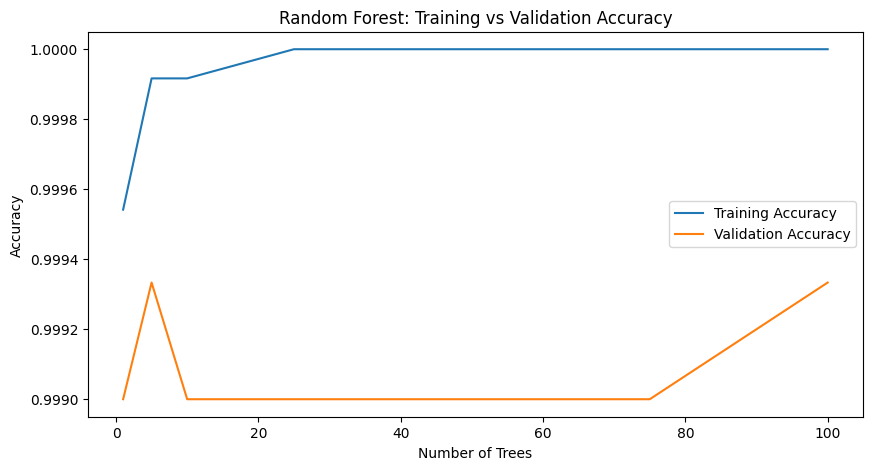

In [22]:
train_acc = []
val_acc = []

tree_values = [1, 5, 10, 25, 50, 75, 100]

for n in tree_values:

    rf = RandomForestClassifier(
        n_estimators=n,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, rf.predict(X_train)))
    val_acc.append(accuracy_score(y_val, rf.predict(X_val)))

plt.figure(figsize=(10,5))

plt.plot(tree_values, train_acc, label="Training Accuracy")
plt.plot(tree_values, val_acc, label="Validation Accuracy")

plt.title("Random Forest: Training vs Validation Accuracy")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 6. Predictions

In [23]:
y_train_pred = rf_model.predict(X_train)
y_val_pred = rf_model.predict(X_val)
y_test_pred = rf_model.predict(X_test)

## 7. Metrics calculation and classification report.

### Metrics function

In [24]:
# Function to evaluate results

def evaluate_model(y_true, y_pred, dataset_name):
    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"{dataset_name} Results")
    print("---------------------")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

### Results

In [27]:
evaluate_model(y_train, y_train_pred, "Training")
evaluate_model(y_val, y_val_pred, "Validation")
evaluate_model(y_test, y_test_pred, "Test")

Training Results
---------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
Validation Results
---------------------
Accuracy : 0.9993
Precision: 0.9993
Recall   : 0.9993
F1 Score : 0.9993
Test Results
---------------------
Accuracy : 0.9987
Precision: 0.9987
Recall   : 0.9987
F1 Score : 0.9987


### Classification report

In [28]:
print(classification_report(y_test, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1500
           1       1.00      1.00      1.00      1500

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



## 8. Confusion matrix

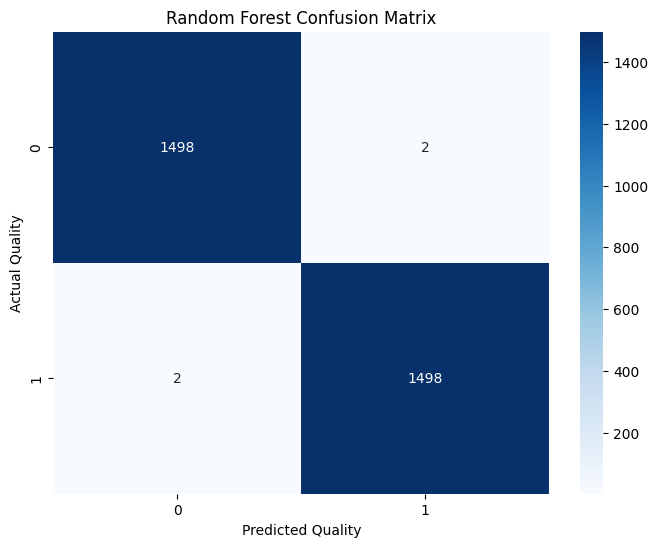

In [31]:
labels = sorted(y_train.unique())

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Quality")
plt.ylabel("Actual Quality")

plt.show()

## 9. Results verification

Due to the high F1-score results we ensure there was no data leakage and results removing different components such as embeddings, stylometric & AST are consistent.

In [37]:
y_train_shuffled = y_train.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

rf_sanity = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_sanity.fit(X_train, y_train_shuffled)

val_pred_random = rf_sanity.predict(X_val)
test_pred_random = rf_sanity.predict(X_test)

print("Validation accuracy with shuffled labels:")
print(accuracy_score(y_val, val_pred_random))

print("Test accuracy with shuffled labels:")
print(accuracy_score(y_test, test_pred_random))

print("Validation F1 with shuffled labels:")
print(f1_score(y_val, val_pred_random, average="weighted"))

print("Test F1 with shuffled labels:")
print(f1_score(y_test, test_pred_random, average="weighted"))

Validation accuracy with shuffled labels:
0.429
Test accuracy with shuffled labels:
0.42633333333333334
Validation F1 with shuffled labels:
0.4276629570747218
Test F1 with shuffled labels:
0.4247978631847794


In [74]:
embedding_columns = [
    col for col in X_train.columns
    if col.startswith("emb_")
]

X_train_emb = X_train[embedding_columns]
X_val_emb = X_val[embedding_columns]
X_test_emb = X_test[embedding_columns]

X_train_extra = X_train[EXTRA_FEATURE_COLUMNS]
X_val_extra = X_val[EXTRA_FEATURE_COLUMNS]
X_test_extra = X_test[EXTRA_FEATURE_COLUMNS]


def quick_eval(Xtr, Xv, Xte, name):
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(Xtr, y_train)

    val_pred = rf.predict(Xv)
    test_pred = rf.predict(Xte)

    print(f"\n{name}")
    print("----------------")
    # print("Val Accuracy :", accuracy_score(y_val, val_pred))
    # print("Val F1       :", f1_score(y_val, val_pred, average="weighted"))
    print("Test Accuracy:", accuracy_score(y_test, test_pred))
    print("Test Precision:", precision_score(y_test, test_pred))
    print("Test Recall:", recall_score(y_test, test_pred))
    print("Test F1      :", f1_score(y_test, test_pred))


quick_eval(X_train_emb, X_val_emb, X_test_emb, "Only embeddings")
quick_eval(X_train_extra, X_val_extra, X_test_extra, "Only stylometric + AST")
quick_eval(X_train, X_val, X_test, "Embeddings + stylometric + AST")


Only embeddings
----------------
Test Accuracy: 0.9986666666666667
Test Precision: 0.9986666666666667
Test Recall: 0.9986666666666667
Test F1      : 0.9986666666666667

Only stylometric + AST
----------------
Test Accuracy: 0.7436666666666667
Test Precision: 0.8884165781083954
Test Recall: 0.5573333333333333
Test F1      : 0.6849651782056534

Embeddings + stylometric + AST
----------------
Test Accuracy: 0.9986666666666667
Test Precision: 0.9986666666666667
Test Recall: 0.9986666666666667
Test F1      : 0.9986666666666667


In [1]:
import pandas as pd

train = pd.read_csv("../Dataframes/df_ai/df_ai_train.csv")
val   = pd.read_csv("../Dataframes/df_ai/df_ai_val.csv")
test  = pd.read_csv("../Dataframes/df_ai/df_ai_test.csv")

train["split"] = "train"
val["split"]   = "val"
test["split"]  = "test"

full = pd.concat([train, val, test], ignore_index=True)

print("Total instances:", len(full))
print("Distribution:", full["split"].value_counts().to_dict())
print("Size of original dataset (unique problems):", len(full) // 2)

for split in ["train", "val", "test"]:
    sub = full[full["split"] == split]
    counts = sub["label"].value_counts().sort_index()
    print(f"\n{split}: {len(sub)} instance → label 0: {counts[0]}, label 1: {counts[1]}")

Total instances: 30000
Distribution: {'train': 24000, 'val': 3000, 'test': 3000}
Size of original dataset (unique problems): 15000

train: 24000 instance → label 0: 12000, label 1: 12000

val: 3000 instance → label 0: 1500, label 1: 1500

test: 3000 instance → label 0: 1500, label 1: 1500


In [3]:
full_label0 = full[full["label"] == 0][["code", "split"]].rename(columns={"code": "human_code", "split": "split_human"})
full_label1 = full[full["label"] == 1][["code", "split"]].rename(columns={"code": "ai_code", "split": "split_ai"})

full_label0 = full_label0.reset_index(drop=True)
full_label1 = full_label1.reset_index(drop=True)

pairs = pd.concat([full_label0, full_label1], axis=1)

# How many pairs have human & AI into different splits?
cross_split = pairs[pairs["split_human"] != pairs["split_ai"]]
print(f"Pairs of human & AI into DIFFERENT splits: {len(cross_split)}")
print(cross_split[["split_human", "split_ai"]].value_counts())

Pairs of human & AI into DIFFERENT splits: 0
Series([], Name: count, dtype: int64)
